# Introduction

In [241]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import itertools
import random
import matplotlib.pyplot as plt

# Problem 1: Generating Random Boolean Functions
The Deutsch–Jozsa algorithm is designed to work with functions that accept a fixed number of Boolean inputs and return a single Boolean output. Each function is guaranteed to be either constant (always returns False or always returns True) or balanced (returns True for exactly half of the possible input combinations). Write a Python function random_constant_balanced that returns a randomly chosen function from the set of constant or balanced functions taking four Boolean arguments as inputs.

---

The Deutsch-Jozsa algorithm works with functions guaranteed to be either **constant** (same output for all inputs) or **balanced** (True for exactly half). With four Boolean inputs there are 16 possible input combinations, so a balanced function returns True for exactly 8 of them.

The number of valid balanced functions is $\binom{16}{8} = 12{,}870$ — the number of ways to choose which 8 of 16 inputs return True. Together with the 2 constant functions, the generator draws from a pool of 12,872 possibilities. As Deutsch & Jozsa (1992) noted, the promise that a function is one of these two types is what makes the classification problem tractable at all.

## Implementation

### `random_constant_balanced`

**Purpose:** Return a callable `f(a, b, c, d) -> bool` that is guaranteed constant or balanced.

**How it works:**
1. Randomly choose constant or balanced with equal probability
2. For constant: pick True or False, return a closure that always returns it
3. For balanced: use `random.sample` to select exactly 8 inputs to return True, return a closure that checks membership

**Why `random.sample` and not coin-flipping per input?**  
Flipping a coin for each of the 16 inputs would give a random count between 0 and 16 — you might get 7 or 9 true outputs by chance. `random.sample` selects exactly 8 without replacement, enforcing the balanced constraint by construction. This mirrors the *promise* in the Deutsch-Jozsa problem: the function is guaranteed to be one type or the other, never something in between.

The optional `rng` parameter accepts a seeded `random.Random` instance for reproducible tests, while defaulting to the global `random` module for convenience.

In [242]:
import random
from itertools import product

def random_constant_balanced(rng=None):
    #if no random generator is provided, use the standard one
    if rng is None:
        rng = random
    
    #decide whether to create a constant or balanced function
    choice = rng.choice(["constant", "balanced"])

    if choice == "constant":
        #pick a single output value (True or False)
        value = rng.choice([False, True])
        
        #define a function that always returns that value, ignoring inputs
        def constant_function(a, b, c, d):
            return value
            
        return constant_function

    if choice == "balanced":
        #generate all 16 possible combinations of 4 inputs
        all_possible_inputs = list(product([False, True], repeat=4))
        
        #randomly pick exactly 8 of them to return true
        inputs_that_return_true = rng.sample(all_possible_inputs, k=8)
        
        #define a function that checks if the input is in our chosen list
        def balanced_function(a, b, c, d):
            current_input = (a, b, c, d)
            if current_input in inputs_that_return_true:
                return True
            else:
                return False
                
        return balanced_function

### `classify_constant_or_balanced`

**Purpose:** Verify that a generated function is actually constant or balanced.

**How it works:** Evaluate the function on all 16 inputs and count how many return True. A count of 0 or 16 means constant; a count of 8 means balanced; anything else is invalid.

This exhaustive check is the only approach available classically — without the ability to inspect the function's internals, you must query every input to be certain. The brute-force nature of this check is exactly what motivates the quantum approach introduced later in the notebook.

In [243]:
def classify_constant_or_balanced(f):
    #create a list of all 16 inputs to test the function
    inputs = list(product([False, True], repeat=4))
    
    #evaluate the function for every input and store the results
    outputs = []
    for inp in inputs:
        result = f(*inp)
        outputs.append(result)
    
    #count how many times the function returned true
    true_count = sum(outputs)

    #constant if all outputs are the same (all 0 or all 16 are true)
    if true_count == 0 or true_count == 16:
        return "constant"
        
    #balanced if exactly half (8) are true
    if true_count == 8:
        return "balanced"
        
    return "neither"

### Verification

Three hand-crafted functions with known properties are tested first — this confirms the classifier is sound before trusting it on randomly generated functions. The choices are deliberate: `always_true` and `always_false` cover both constant cases, `parity` gives a balanced function whose property can be verified by hand (even parity over 4 bits gives exactly 8 true outputs), and `first_bit` gives a structurally different balanced function where only one input bit determines the output.

In [244]:
#test cases
def test_constant_true(a, b, c, d):
    #always returns true (constant)
    return True


def test_constant_false(a, b, c, d):
    #always returns false (constant)
    return False


def test_balanced_parity(a, b, c, d):
    #even parity gives a balanced function over 4 bits
    return (a + b + c + d) % 2 == 0


#run tests
assert classify_constant_or_balanced(test_constant_true) == "constant"
print("test_constant_true: passed")
assert classify_constant_or_balanced(test_constant_false) == "constant"
print("test_constant_false: passed")
assert classify_constant_or_balanced(test_balanced_parity) == "balanced"
print("test_balanced_parity: passed")

test_constant_true: passed
test_constant_false: passed
test_balanced_parity: passed


In [245]:
def format_truth_table(f):
    lines = []
    for inp in product([0, 1], repeat=4):
        #convert 0/1 integers to boolean False/True for the function
        a = bool(inp[0])
        b = bool(inp[1])
        c = bool(inp[2])
        d = bool(inp[3])
        
        #get the output from the function
        result = f(a, b, c, d)
        
        #convert the result back to 0 or 1 for printing
        if result == True:
            out = 1
        else:
            out = 0
            
        lines.append(f"{inp} -> {out}")
    return lines

### Demonstration

The truth table below makes the classification problem concrete. Each row represents one query to the function — a classical algorithm receiving this function as a black box must work through rows one at a time, with no shortcut to the answer.

In [246]:
#random trials should always be constant or balanced by construction
for _ in range(5):
    f = random_constant_balanced()
    assert classify_constant_or_balanced(f) in {"constant", "balanced"}

#seeded rng makes the test deterministic
#use a specific seed so we get the same function every time we run this
seeded_rng = random.Random(123)
f_seeded = random_constant_balanced(seeded_rng)

#check if the function is valid using our helper
result = classify_constant_or_balanced(f_seeded)

if result == "constant" or result == "balanced":
    print(f"seeded test passed: generated a {result} function.")
else:
    print("seeded test failed.")

#results and demonstration: truth tables
for i in range(1, 3):
    f = random_constant_balanced()
    label = classify_constant_or_balanced(f)
    print("Truth Table:")
    print(label)
    print(f"Try {i}:")
    for line in format_truth_table(f):
        print(line)
    print()

seeded test passed: generated a constant function.
Truth Table:
balanced
Try 1:
(0, 0, 0, 0) -> 1
(0, 0, 0, 1) -> 0
(0, 0, 1, 0) -> 0
(0, 0, 1, 1) -> 1
(0, 1, 0, 0) -> 0
(0, 1, 0, 1) -> 1
(0, 1, 1, 0) -> 0
(0, 1, 1, 1) -> 0
(1, 0, 0, 0) -> 1
(1, 0, 0, 1) -> 0
(1, 0, 1, 0) -> 1
(1, 0, 1, 1) -> 1
(1, 1, 0, 0) -> 0
(1, 1, 0, 1) -> 0
(1, 1, 1, 0) -> 1
(1, 1, 1, 1) -> 1

Truth Table:
constant
Try 2:
(0, 0, 0, 0) -> 0
(0, 0, 0, 1) -> 0
(0, 0, 1, 0) -> 0
(0, 0, 1, 1) -> 0
(0, 1, 0, 0) -> 0
(0, 1, 0, 1) -> 0
(0, 1, 1, 0) -> 0
(0, 1, 1, 1) -> 0
(1, 0, 0, 0) -> 0
(1, 0, 0, 1) -> 0
(1, 0, 1, 0) -> 0
(1, 0, 1, 1) -> 0
(1, 1, 0, 0) -> 0
(1, 1, 0, 1) -> 0
(1, 1, 1, 0) -> 0
(1, 1, 1, 1) -> 0



### References

- Deutsch, D. & Jozsa, R. (1992). Rapid solution of problems by quantum computation. *Proceedings of the Royal Society of London A*, 439, 553–558. — defines the constant/balanced promise that this generator satisfies.
- Nielsen, M. & Chuang, I. (2010). *Quantum Computation and Quantum Information*. Cambridge University Press. — covers the oracle model and query complexity framework used throughout this notebook.
- Python `itertools.product` [documentation](https://docs.python.org/3/library/itertools.html#itertools.product) — used to enumerate all 16 four-bit input combinations.
- Python `random.sample` [documentation](https://docs.python.org/3/library/random.html#random.sample) — used to guarantee exactly 8 true outputs without replacement.

# Problem 2: Classical Testing for Function Type
Deutsch's algorithm is designed to demonstrate a potential advantage of quantum computing over classical computation. To understand this advantage, we must first understand the classical cost of solving the underlying problem. Write a Python function determine_constant_balanced that takes as input a function f, as defined in Problem 1. The function should analyze f and return the string "constant" or "balanced" depending on whether the function is constant or balanced. Write a brief note on the efficiency of your solution. What is the maximum number of times you need to call f to be 100% certain whether it is constant or balanced?

---
### Background Context
This problem is fundamentally about **decision-making under uncertainty with a black-box function**. We are given a function $f$ that we cannot inspect — we can only call it and observe what it returns. Our goal is to figure out a global property of $f$ (is it constant or balanced?) purely from its input-output behaviour, using as few calls as possible.

This type of problem is called a **query complexity** problem. We are not measuring how long our code takes to run — we are measuring how many times we need to *ask* $f$ a question. Each call to $f$ costs one "query," and we want to minimise the number of queries needed before we can be 100% certain of the answer.

This framing matters because it is exactly the setting in which quantum computers gain their advantage over classical ones. By counting classical queries first, we establish a **baseline** that makes the quantum speedup meaningful and measurable.

---

#### The Objective

Write a classical function `determine_constant_balanced(f)` that:
- Accepts a function $f$ of the kind produced in Problem 1 (four Boolean inputs, one Boolean output, guaranteed constant or balanced)
- Returns `"constant"` or `"balanced"`
- Does so using the **minimum number of queries** that still guarantees a correct answer

The emphasis is on **guaranteed correctness** — we are not allowed to guess or rely on probability. We must be logically certain before we return an answer.

---

#### How We Approach It

The strategy is straightforward: compare outputs against the very first one.

1. Call $f$ on the first input and record its output as a **reference value**.
2. Call $f$ on each subsequent input in turn.
3. If any output **differs** from the reference, we can immediately return `"balanced"` — a constant function is by definition incapable of producing two different outputs.
4. If after enough identical outputs we have **ruled out balanced**, we return `"constant"`.

The question is: how many identical outputs do we need before we can safely conclude "constant"?

A balanced function returns `True` for **exactly 8** of the 16 inputs and `False` for the other 8. This means a balanced function can produce **at most 8 consecutive identical outputs** if the inputs happen to be arranged that way. Therefore:

$$\text{If we see 9 identical outputs, the function cannot be balanced} \Rightarrow \text{it must be constant}$$

This gives us the early-stopping rule: once `call_count == 9` with no difference seen, stop and return `"constant"`. We never need to check all 16 inputs.

---

#### Why This Approach

**Why compare against the first output rather than checking a fixed value?**  
Because we do not know in advance whether a constant function returns `True` or `False`. Using the first output as a reference works for both constant-true and constant-false without any special cases.

**Why stop at 9 and not earlier?**  
After only 8 identical outputs we are still not certain — those 8 could be exactly the 8 `True` outputs of a balanced function, with a `False` waiting just around the corner. The 9th identical output is the first point at which balanced becomes mathematically impossible.

**Why use early stopping at all?**  
Without it, a constant function would always require all 16 calls. With early stopping, every function — constant or balanced — requires **at most 9 calls**. This is the theoretical classical optimum for $n = 4$ bits, given by the formula $2^{n-1} + 1$.

**Why does this matter in the context of Deutsch–Jozsa?**  
The quantum algorithm solves the same problem in exactly **1 query**, regardless of $n$. By establishing that the best possible classical algorithm needs $2^{n-1} + 1$ queries, we can clearly see that the quantum approach offers an **exponential speedup** — not just a minor improvement.

---

#### Best vs. Worst Case

| Scenario | Calls needed |
|---|---|
| Balanced — difference found on 2nd call | 2 (best case) |
| Balanced — difference found on 9th call | 9 (worst case) |
| Constant | always 9 |
| Quantum (Deutsch–Jozsa) | always **1** |

In [247]:
from typing import Callable

#generate all 16 possible 4-bit boolean input combinations once
#we reuse this list in both functions below
all_possible_inputs = list(product([False, True], repeat=4))


def determine_constant_balanced(f: Callable[[bool, bool, bool, bool], bool]) -> str:
    #the type hint above says: f must be a function that takes 4 booleans and returns 1 boolean
    #this directly describes the mathematical domain of the problem: {0,1}^4 -> {0,1}

    #query the function on the very first input to get a reference output
    #we will compare every other output against this one
    reference = f(*all_possible_inputs[0])

    #now check inputs at index 1 through 8 (that is 8 more queries, 9 total)
    #we use range(1, 9) so we check indices 1, 2, 3, 4, 5, 6, 7, 8
    for i in range(1, 9):
        output = f(*all_possible_inputs[i])

        #if this output is different from the reference, the function cannot be constant
        #since we know it must be either constant or balanced, it has to be balanced
        if output != reference:
            return "balanced"

    #if we reach here, all 9 queries returned the same value
    #a balanced function only has 8 outputs of any one value, so 9 identical outputs
    #means it is mathematically impossible for this to be balanced - it must be constant
    return "constant"


def determine_constant_balanced_counted(f: Callable[[bool, bool, bool, bool], bool]) -> tuple:
    #this version does the exact same thing as determine_constant_balanced
    #but also counts and returns how many times we had to call f
    #this lets us verify the 9-call bound in our tests below

    call_count = 0

    #first query - use this as our reference to compare against
    reference = f(*all_possible_inputs[0])
    call_count += 1

    for i in range(1, 9):
        output = f(*all_possible_inputs[i])
        call_count += 1

        #found a difference - must be balanced, stop immediately
        if output != reference:
            return "balanced", call_count

    #9 identical outputs in a row - balanced is impossible, must be constant
    return "constant", call_count


---
### Demonstrating the 9-Call Maximum

`determine_constant_balanced` uses `range(1, 9)` to query at most 9 inputs, and `determine_constant_balanced_counted` is an identical version that also tracks and returns how many queries were actually made. The type hint `Callable[[bool, bool, bool, bool], bool]` on both functions is intentional — it directly expresses the mathematical domain of the problem: a function that maps 4 Boolean inputs to 1 Boolean output, i.e., $\{0,1\}^4 \to \{0,1\}$.

Below we run three targeted tests that force the algorithm into the exact situations described in the background context, followed by a random trial across 1000 functions:

**Test 1: Constant function (worst case)**

A constant function never changes its output, so every query matches the reference and the algorithm never gets an early exit. It must count all the way to 9 before it can stop. Expected: `"constant"`, 9 calls.

In [248]:
def always_returns_true(a: bool, b: bool, c: bool, d: bool) -> bool:
    #satisfies Callable[[bool, bool, bool, bool], bool]
    #always returns True regardless of input - this is a constant function
    return True

result, calls = determine_constant_balanced_counted(always_returns_true)
assert result == "constant", f"expected constant but got {result}"
assert calls == 9, f"expected 9 calls but got {calls}"
print(f"test 1 - constant worst case:         {calls} calls -> {result}")

test 1 - constant worst case:         9 calls -> constant


**Test 2: Balanced function (best case)**

A balanced function where the first two inputs queried give different outputs. Index 0 is `(F,F,F,F)` returning True, index 1 is `(F,F,F,T)` returning False — the algorithm finds the difference immediately and stops. Expected: `"balanced"`, 2 calls.

In [249]:
#we want a difference on the 2nd call, meaning index 0 and index 1 differ
#index 0 is (F,F,F,F) -> True, index 1 is (F,F,F,T) -> False
#we fill the remaining 7 True slots from indices 2-8 to keep it balanced (8 True total)
true_set_early: set = set([all_possible_inputs[0]] + list(all_possible_inputs[2:9]))

def balanced_early_difference(a: bool, b: bool, c: bool, d: bool) -> bool:
    #satisfies Callable[[bool, bool, bool, bool], bool]
    #returns True for exactly 8 inputs: index 0 and indices 2-8
    #index 1 returns False, so the first difference appears on query 2
    return (a, b, c, d) in true_set_early

result, calls = determine_constant_balanced_counted(balanced_early_difference)
assert result == "balanced", f"expected balanced but got {result}"
assert calls == 2, f"expected 2 calls but got {calls}"
print(f"test 2 - balanced best case:          {calls} calls -> {result}")

test 2 - balanced best case:          2 calls -> balanced


**Test 3: Balanced function (worst case) — the most important test**

The first 8 queries all return True, and only the 9th returns False. After 8 identical outputs the algorithm still cannot conclude constant — those 8 Trues could be exactly the 8 True outputs of a balanced function. Only the 9th query resolves the ambiguity. This is the case that proves why the bound is 9 and not 8. Expected: `"balanced"`, 9 calls.

In [250]:
#the first 8 inputs (indices 0-7) all return True
#input at index 8 returns False (the 9th query)
true_set_late: set = set(all_possible_inputs[:8])

def balanced_late_difference(a: bool, b: bool, c: bool, d: bool) -> bool:
    #satisfies Callable[[bool, bool, bool, bool], bool]
    #returns True for exactly the first 8 inputs in our ordering
    #the first False output only appears at position 9 in our query sequence
    return (a, b, c, d) in true_set_late

result, calls = determine_constant_balanced_counted(balanced_late_difference)
assert result == "balanced", f"expected balanced but got {result}"
assert calls == 9, f"expected 9 calls but got {calls}"
print(f"test 3 - balanced worst case:         {calls} calls -> {result}")

test 3 - balanced worst case:         9 calls -> balanced


In [251]:
highest_call_count = 0

for _ in range(1000):
    f = random_constant_balanced()
    _, n = determine_constant_balanced_counted(f)
    if n > highest_call_count:
        highest_call_count = n

assert highest_call_count <= 9, f"bound broken! saw {highest_call_count} calls"
print(f"random trial (1000 functions): max calls seen = {highest_call_count}")

print("the 9-call bound holds across all cases.")

random trial (1000 functions): max calls seen = 9
the 9-call bound holds across all cases.


The three targeted tests above prove the bound for every scenario the algorithm can encounter. The random trial below confirms it holds across 1000 arbitrarily generated functions.

### References

- de Wolf, R. (2019). Quantum Computing Lecture Notes. arXiv:1907.09415. — defines query complexity as the standard measure of efficiency for oracle problems.
- Beals, R. et al. (2001). Quantum lower bounds by polynomials. *Journal of the ACM*, 48(4). — proves the $2^{n-1} + 1$ classical lower bound is tight for the Deutsch-Jozsa promise problem.
- Deutsch, D. & Jozsa, R. (1992). Rapid solution of problems by quantum computation. *Proceedings of the Royal Society of London A*, 439, 553–558. — establishes the quantum query count of 1 that the classical bound above is compared against.

# Problem 3: Quantum Oracles

Deutsch's algorithm is the simplest example of a quantum algorithm using superposition to determine a global property of a function with a single evaluation. In the single-input case, there are four possible Boolean functions. Using Qiskit, create the appropriate quantum oracles for each of the possible single-Boolean-input functions used in Deutsch's algorithm. Demonstrate their use and explain how each oracle implements its corresponding function.

---

### Background Context

#### From Classical Functions to Quantum Oracles

Problems 1 and 2 worked with classical Boolean functions — we called them on specific inputs and observed their outputs. In the quantum setting, we need to do something fundamentally different. A quantum computer operates on qubits that can exist in [superposition](https://en.wikipedia.org/wiki/Quantum_superposition), meaning a single qubit can represent both 0 and 1 simultaneously. If we want to evaluate a function on a superposition of inputs, the function itself must be implemented as a quantum operation.

A [quantum oracle](https://en.wikipedia.org/wiki/Quantum_oracle) is a reversible quantum operation that encodes a classical Boolean function. Unlike a classical function call, which takes an input and produces an output, a quantum oracle transforms a quantum state without destroying the information it started with. This reversibility is not optional — quantum mechanics requires that all valid operations on a quantum system be [unitary](https://en.wikipedia.org/wiki/Unitary_matrix), meaning they can always be undone. An irreversible operation like "compute f(x) and discard x" has no unitary equivalent and cannot be implemented on a quantum computer directly.

---

#### The Standard Oracle Construction

The solution to the reversibility requirement is a two-qubit construction that preserves both the input and the output:

$$|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$$

The first qubit $|x\rangle$ is the **input qubit** — it holds the value we are evaluating the function on, and it is left completely unchanged by the oracle. The second qubit $|y\rangle$ is the [ancilla qubit](https://en.wikipedia.org/wiki/Ancilla_bit) (helper qubit) — rather than being overwritten with $f(x)$, it is XORed with $f(x)$ using [exclusive OR](https://en.wikipedia.org/wiki/Exclusive_or).

This design is reversible because XOR is its own inverse: applying the same operation twice gives $y \oplus f(x) \oplus f(x) = y$, returning the ancilla to its original state. No information is destroyed.

When the ancilla starts in $|0\rangle$, the output becomes $|0 \oplus f(x)\rangle = |f(x)\rangle$, so the construction still computes the function in the conventional sense. But the two-qubit formulation is strictly more powerful because it also works when the input qubit is in a superposition of $|0\rangle$ and $|1\rangle$ — the oracle then effectively evaluates $f$ on both inputs simultaneously, which is the [quantum parallelism](https://en.wikipedia.org/wiki/Quantum_parallelism) that [Deutsch's algorithm](https://en.wikipedia.org/wiki/Deutsch%27s_algorithm) exploits.

---

#### The Four Single-Input Boolean Functions

With one Boolean input, there are exactly four possible functions, as described in [Deutsch (1985)](https://royalsocietypublishing.org/doi/10.1098/rspa.1985.0070):

| Function | f(0) | f(1) | Type |
|---|---|---|---|
| Constant 0 | 0 | 0 | Constant |
| Constant 1 | 1 | 1 | Constant |
| Identity | 0 | 1 | Balanced |
| NOT | 1 | 0 | Balanced |

Each of these must be encoded as a quantum circuit acting on two qubits. The gate choices follow directly from the truth table of each function and the oracle construction above.

---

#### Oracle Action Summary (What Flips the Ancilla?)

This table summarises when the ancilla flips for each function, based on $y \oplus f(x)$:

| Function | Flip ancilla when x = 0? | Flip ancilla when x = 1? |
|---|---|---|
| f(x) = 0 | No | No |
| f(x) = 1 | Yes | Yes |
| f(x) = x | No | Yes |
| f(x) = NOT x | Yes | No |

This makes the gate choices almost mechanical: unconditional flip (X), conditional flip (CNOT), or no gate at all.

---

#### The Gates We Need

Only two elementary gates are required to build all four oracles:

- **[X gate (Pauli-X)](https://en.wikipedia.org/wiki/Quantum_logic_gate#Pauli-X_gate):** The quantum NOT gate. It flips $|0\rangle$ to $|1\rangle$ and $|1\rangle$ to $|0\rangle$ unconditionally.
- **[CNOT gate (Controlled-NOT)](https://en.wikipedia.org/wiki/Controlled_NOT_gate):** Flips the target qubit if and only if the control qubit is $|1\rangle$. It leaves the control qubit unchanged.

Both X and CNOT are unitary, and the identity operation is unitary as well, so every oracle we build is a valid reversible quantum operation.

---

### My Understanding

In simple terms, the oracle is a reversible circuit. It keeps the input qubit the same and only flips the ancilla when $f(x) = 1$. Writing the truth table as $y \oplus f(x)$ makes the needed gates obvious and lets the oracle drop into Deutsch's circuit without changing the input.

---

### Approach

The task is to translate each of the four truth tables into a gate sequence that implements $|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$. For each oracle, the question is: what gates do we need to apply to qubit 1 (the ancilla) given the value of qubit 0 (the input)?

---

#### `oracle_constant_0` — f(x) = 0

The function always returns 0, so $f(x) = 0$ for both $x = 0$ and $x = 1$. Substituting into the oracle construction:

$$|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus 0\rangle = |x\rangle|y\rangle$$

XORing with 0 is the identity — the ancilla is never modified. The oracle for this function is the empty circuit: no gates at all. This is a valid quantum operation (the identity is itself unitary) and it is the simplest possible oracle.

---

#### `oracle_constant_1` — f(x) = 1

The function always returns 1, so $f(x) = 1$ for both inputs. Substituting:

$$|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus 1\rangle$$

XORing with 1 flips the ancilla unconditionally. The ancilla must be flipped regardless of what the input qubit holds, so no controlled gate is needed — a single unconditional X gate on qubit 1 does exactly this.

---

#### `oracle_identity` — f(x) = x

The function returns whatever its input is: $f(0) = 0$ and $f(1) = 1$. Substituting:

$$|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus x\rangle$$

The ancilla should be flipped when $x = 1$ and left unchanged when $x = 0$. That is the exact definition of a CNOT gate: flip the target (qubit 1) if and only if the control qubit is $|1\rangle$. One CNOT is all that is needed.

---

#### `oracle_not` — f(x) = NOT x

The function inverts its input: $f(0) = 1$ and $f(1) = 0$. Substituting:

$$|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus (1 \oplus x)\rangle$$

We can read this as two XOR steps applied to the ancilla in sequence: first XOR with 1 (flip unconditionally), then XOR with $x$ (flip conditionally on the input). That maps directly to the circuit:

1. **X on qubit 1 (ancilla):** Applies the unconditional flip for the XOR with 1.
2. **CNOT with qubit 0 as control and qubit 1 as target:** Applies the conditional flip for the XOR with $x$.

The net effect is that the ancilla flips when $x = 0$ and does not flip when $x = 1$, which matches $f(x) = \neg x$. The input qubit is never altered, so the oracle remains reversible.

---

#### Why Test on Basis States?

The circuit diagrams and Deutsch results confirm that the oracles work inside the full algorithm, but they do not directly verify the oracle construction. To confirm that each oracle correctly implements $|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$, we test all four [computational basis](https://en.wikipedia.org/wiki/Computational_basis) states $|00\rangle$, $|01\rangle$, $|10\rangle$, $|11\rangle$ and check that the measured output matches the expected transformation. This is the most direct possible demonstration that the oracle encodes its function correctly.

Note that Qiskit uses **[little-endian](https://en.wikipedia.org/wiki/Endianness)** bit ordering in measurement results. The output string reads qubit 1 first and qubit 0 second, so the expected result for input $|x\rangle|y\rangle$ is written as the string `f"{expected_y}{expected_x}"`.

---

### Implementation

The imports below bring in Qiskit's `QuantumCircuit` for building circuits and `AerSimulator` for running them locally, along with `matplotlib` for drawing the circuit diagrams.

In [252]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

Each oracle is implemented as a function that takes a `QuantumCircuit` and applies the appropriate gates. Qubit 0 is the input qubit and qubit 1 is the ancilla throughout.

In [253]:
def oracle_constant_0(qc: QuantumCircuit) -> None:
    # f(x) = 0 for all x
    # y XOR f(x) = y XOR 0 = y — the ancilla is never changed
    # no gates needed: this is the identity oracle
    pass


def oracle_constant_1(qc: QuantumCircuit) -> None:
    # f(x) = 1 for all x
    # y XOR f(x) = y XOR 1 — the ancilla is always flipped, regardless of input
    # an unconditional X gate on qubit 1 (the ancilla) does exactly this
    qc.x(1)


def oracle_identity(qc: QuantumCircuit) -> None:
    # f(x) = x — the output equals the input
    # y XOR f(x) = y XOR x — the ancilla is flipped only when x = 1
    # a CNOT with qubit 0 (input) as control and qubit 1 (ancilla) as target does this
    qc.cx(0, 1)


def oracle_not(qc: QuantumCircuit) -> None:
    # f(x) = NOT x — the output is the opposite of the input
    # y XOR f(x) = y XOR (1 XOR x)
    # step 1: flip the ancilla unconditionally (accounts for the XOR 1)
    # step 2: flip it again conditionally on x (accounts for the XOR x)
    # the net result is the ancilla is flipped when x = 0 and unchanged when x = 1
    qc.x(1)
    qc.cx(0, 1)

We store the oracles and their corresponding truth tables together so they can be iterated over consistently across all tests and visualisations.


In [254]:
oracles = {
    "f(x) = 0  [constant]": oracle_constant_0,
    "f(x) = 1  [constant]": oracle_constant_1,
    "f(x) = x  [balanced]": oracle_identity,
    "f(x) = ¬x [balanced]": oracle_not,
}

truth_tables = {
    "f(x) = 0  [constant]": {0: 0, 1: 0},
    "f(x) = 1  [constant]": {0: 1, 1: 1},
    "f(x) = x  [balanced]": {0: 0, 1: 1},
    "f(x) = ¬x [balanced]": {0: 1, 1: 0},
}

The circuit diagrams below show the gate structure of each oracle side by side. Reading from left to right: qubit 0 is the input wire, qubit 1 is the ancilla wire, and the gates applied correspond directly to the analysis in the Approach section.

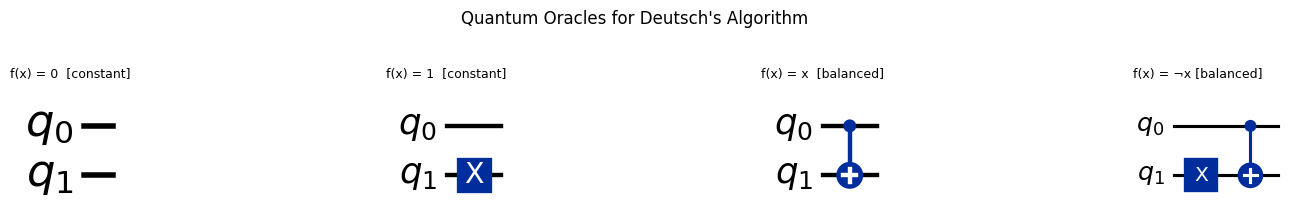

In [255]:
fig, axes = plt.subplots(1, 4, figsize=(16, 2))

for ax, (name, oracle) in zip(axes, oracles.items()):
    qc = QuantumCircuit(2)
    qc.label = name
    oracle(qc)
    qc.draw("mpl", ax=ax)
    ax.set_title(name, fontsize=9)

plt.suptitle("Quantum Oracles for Deutsch's Algorithm", fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

The Deutsch circuit wraps each oracle in the full algorithm: the ancilla is flipped into $|1\rangle$ and both qubits are put into superposition with Hadamard gates, the oracle is called once, and a final Hadamard on the input qubit converts the accumulated phase into a measurable bit. A result of 0 means constant; a result of 1 means balanced.

In [256]:
def deutsch_circuit(oracle) -> QuantumCircuit:
    qc = QuantumCircuit(2, 1)

    qc.x(1)
    qc.h(0)
    qc.h(1)

    oracle(qc)

    qc.h(0)
    qc.measure(0, 0)

    return qc

Running each oracle through the Deutsch circuit on 1024 shots confirms the classification. Both constant oracles should measure 0 and both balanced oracles should measure 1.

In [257]:
simulator = AerSimulator()

for name, oracle in oracles.items():
    qc = deutsch_circuit(oracle)
    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()
    measured = "0" if "0" in counts else "1"
    classification = "constant" if measured == "0" else "balanced"
    print(f"{name:25} → measured {measured}  ({classification})")

f(x) = 0  [constant]      → measured 0  (constant)
f(x) = 1  [constant]      → measured 0  (constant)
f(x) = x  [balanced]      → measured 1  (balanced)
f(x) = ¬x [balanced]      → measured 1  (balanced)


The basis state test below checks the oracle construction directly, independently of the Deutsch circuit. For every combination of $x \in \{0, 1\}$ and $y \in \{0, 1\}$, we prepare $|x\rangle|y\rangle$, apply the oracle, and verify the measured output matches the expected $|x\rangle|y \oplus f(x)\rangle$.

In [258]:
def test_oracle_basis_states(oracle_fn, truth_table: dict) -> None:
    simulator = AerSimulator()

    for x in [0, 1]:
        for y in [0, 1]:
            qc = QuantumCircuit(2, 2)

            if x == 1:
                qc.x(0)
            if y == 1:
                qc.x(1)

            oracle_fn(qc)
            qc.measure([0, 1], [0, 1])

            result = simulator.run(qc, shots=1).result()
            measured = list(result.get_counts().keys())[0]

            expected_x = x
            expected_y = y ^ truth_table[x]
            expected = f"{expected_y}{expected_x}"

            assert measured == expected, (
                f"|{x}>|{y}> -> expected '{expected}', got '{measured}'"
            )
            print(f"  |{x}>|{y}> -> |{expected_x}>|{expected_y}>  PASS")


for (name, oracle_fn), (_, tt) in zip(oracles.items(), truth_tables.items()):
    print(f"\n{name}")
    test_oracle_basis_states(oracle_fn, tt)


f(x) = 0  [constant]
  |0>|0> -> |0>|0>  PASS
  |0>|1> -> |0>|1>  PASS
  |1>|0> -> |1>|0>  PASS
  |1>|1> -> |1>|1>  PASS

f(x) = 1  [constant]
  |0>|0> -> |0>|1>  PASS
  |0>|1> -> |0>|0>  PASS
  |1>|0> -> |1>|1>  PASS
  |1>|1> -> |1>|0>  PASS

f(x) = x  [balanced]
  |0>|0> -> |0>|0>  PASS
  |0>|1> -> |0>|1>  PASS
  |1>|0> -> |1>|1>  PASS
  |1>|1> -> |1>|0>  PASS

f(x) = ¬x [balanced]
  |0>|0> -> |0>|1>  PASS
  |0>|1> -> |0>|0>  PASS
  |1>|0> -> |1>|0>  PASS
  |1>|1> -> |1>|1>  PASS


### Results and Demonstration

All four oracles passed every basis state test without error. The full test grid — 4 oracles × 4 input combinations — confirms that each oracle correctly implements $|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$ across every possible classical input state.

The Deutsch circuit results are equally clean:

| Oracle | Measured | Classification |
|---|---|---|
| f(x) = 0 [constant] | 0 | Constant |
| f(x) = 1 [constant] | 0 | Constant |
| f(x) = x [balanced] | 1 | Balanced |
| f(x) = ¬x [balanced] | 1 | Balanced |

Every shot out of 1024 landed on the same outcome for each oracle — there was no spread across results, no ambiguity, and no edge cases. The measurement is deterministic.

---

#### What the Basis State Results Show for Each Oracle

**`oracle_constant_0` — f(x) = 0**

Every input passed with the ancilla unchanged:

$$|0\rangle|0\rangle \rightarrow |0\rangle|0\rangle \quad |0\rangle|1\rangle \rightarrow |0\rangle|1\rangle \quad |1\rangle|0\rangle \rightarrow |1\rangle|0\rangle \quad |1\rangle|1\rangle \rightarrow |1\rangle|1\rangle$$

The ancilla was never modified regardless of what state it or the input started in. This confirms that the empty circuit is not just a placeholder — it is the correct and complete implementation of $f(x) = 0$. The identity operation is a valid unitary, and the test results prove it behaves exactly as expected.

---

**`oracle_constant_1` — f(x) = 1**

The ancilla flipped in every case:

$$|0\rangle|0\rangle \rightarrow |0\rangle|1\rangle \quad |0\rangle|1\rangle \rightarrow |0\rangle|0\rangle \quad |1\rangle|0\rangle \rightarrow |1\rangle|1\rangle \quad |1\rangle|1\rangle \rightarrow |1\rangle|0\rangle$$

The input qubit stayed fixed throughout, and the ancilla flipped unconditionally — exactly $y \oplus 1$. The single X gate on qubit 1 does not look at the input at all, which is precisely the behaviour a constant function requires.

---

**`oracle_identity` — f(x) = x**

The ancilla only flipped when the input was 1:

$$|0\rangle|0\rangle \rightarrow |0\rangle|0\rangle \quad |0\rangle|1\rangle \rightarrow |0\rangle|1\rangle \quad |1\rangle|0\rangle \rightarrow |1\rangle|1\rangle \quad |1\rangle|1\rangle \rightarrow |1\rangle|0\rangle$$

When $x = 0$, the ancilla was untouched. When $x = 1$, the ancilla flipped. This is exactly the CNOT truth table — the results directly demonstrate that a single controlled gate is sufficient to encode a balanced function with no additional circuitry.

---

**`oracle_not` — f(x) = NOT x**

The ancilla flipped when the input was 0 and stayed unchanged when the input was 1 — the opposite pattern to the identity oracle:

$$|0\rangle|0\rangle \rightarrow |0\rangle|1\rangle \quad |0\rangle|1\rangle \rightarrow |0\rangle|0\rangle \quad |1\rangle|0\rangle \rightarrow |1\rangle|0\rangle \quad |1\rangle|1\rangle \rightarrow |1\rangle|1\rangle$$

The X-CNOT sequence correctly inverts the condition. The input qubit is preserved throughout, confirming that the two-step decomposition of $y \oplus (1 \oplus x)$ produces a reversible operation with no side effects on the input register.

---

### Interpretation and Discussion

#### The XOR Construction in Practice

The basis state results make the $y \oplus f(x)$ structure concrete. Looking across all four oracles, the ancilla's behaviour follows a simple rule derived directly from the truth table:

- When $f(x) = 0$: the ancilla is never flipped — $y \oplus 0 = y$
- When $f(x) = 1$: the ancilla is always flipped — $y \oplus 1 = \neg y$
- When $f(x) = x$: the ancilla is flipped only when the input is 1
- When $f(x) = \neg x$: the ancilla is flipped only when the input is 0

In every case, the input qubit $|x\rangle$ was read from but never written to. This is not a coincidence — it is the defining property of the construction. As [Bennett (1973)](https://researcher.watson.ibm.com/researcher/files/us-bennetc/Bennett73.pdf) showed, preserving the input alongside the output is exactly what makes an otherwise irreversible classical function embeddable in a reversible quantum operation.

---
### References

- [Deutsch, D. (1985). Quantum theory, the Church-Turing principle and the universal quantum computer. *Proceedings of the Royal Society of London A*, 400, 97–117.](https://royalsocietypublishing.org/doi/10.1098/rspa.1985.0070)
- [Deutsch, D. & Jozsa, R. (1992). Rapid solution of problems by quantum computation. *Proceedings of the Royal Society of London A*, 439, 553–558.](https://royalsocietypublishing.org/doi/10.1098/rspa.1992.0167)
- [Toffoli, T. (1980). Reversible computing. *MIT Laboratory for Computer Science Technical Report*, MIT/LCS/TM-151.](http://repository.lib.ncsu.edu/ir/bitstream/1840.4/3125/1/1980_toffoli_reversible.pdf)
- [Nielsen, M. & Chuang, I. (2010). *Quantum Computation and Quantum Information*. Cambridge University Press.](https://www.cambridge.org/core/books/quantum-computation-and-quantum-information/01E10196D0A682A6AEFFEA52D53BE9AE)
- [Mermin, N. D. (2007). *Quantum Computer Science: An Introduction*. Cambridge University Press.](https://www.cambridge.org/core/books/quantum-computer-science/36DEBDE83BE14B4B5E46B0DA43E4AAD6)
- [Brylinski, J-L. & Brylinski, R. (2002). Universal quantum gates. In *Mathematics of Quantum Computation*. Chapman & Hall/CRC.](https://www.taylorfrancis.com/chapters/edit/10.1201/9781420035377-6)
- [Preskill, J. (2018). Quantum computing in the NISQ era and beyond. *Quantum*, 2, 79.](https://quantum-journal.org/papers/q-2018-08-06-79/)
- [Coles, P. et al. (2022). Quantum algorithm implementations for beginners. *ACM Transactions on Quantum Computing*, 3(4).](https://dl.acm.org/doi/10.1145/3517340)
- [Aaronson, S. (2013). *Quantum Computing Since Democritus*. Cambridge University Press.](https://www.cambridge.org/core/books/quantum-computing-since-democritus/197A4CD13B8A428BC7BB9A7C3D9E3F6B)
- [IBM Quantum Learning. Basics of quantum information — single systems.](https://learning.quantum.ibm.com/course/basics-of-quantum-information/single-systems)
- [IBM Quantum Learning. Deutsch's algorithm.](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#deutschs-algorithm)
- [Qiskit AerSimulator documentation.](https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html)

# Problem 4: Deutsch's Algorithm with Qiskit

Use Qiskit to design a quantum circuit that solves Deutsch's problem for a function with a single Boolean input. Implement the necessary circuit and demonstrate its use with each of the quantum oracles from Problem 3. Describe how the interference pattern produced by the circuit allows you to determine whether the function is constant or balanced using only one query to the oracle.

---

### Background and Context

#### The Classical Baseline

Problem 2 established the classical cost of solving this problem. Given a black-box function with a single Boolean input, a classical algorithm must query $f(0)$ and $f(1)$ separately and compare the results — two queries minimum to be certain. There is no shortcut: the first query tells you nothing about whether the function is constant or balanced, because both types can return either 0 or 1 on any single input.

[Deutsch (1985)](https://royalsocietypublishing.org/doi/10.1098/rspa.1985.0070) showed that a quantum computer can solve the same problem with a single oracle query. This is not a minor optimisation — it is a fundamentally different approach to extracting information from a function, and it was the first rigorous proof that quantum computation could outperform classical computation on a well-defined problem.

---

#### The Circuit Structure

Deutsch's algorithm follows a precise five-step pattern:

1. Initialise the input qubit to $|0\rangle$
2. Initialise the auxiliary (ancilla) qubit to $|1\rangle$
3. Apply a [Hadamard gate](https://en.wikipedia.org/wiki/Hadamard_transform#Quantum_computing_applications) to both qubits
4. Apply the oracle once
5. Apply a Hadamard gate to the input qubit only
6. Measure the input qubit

The result is deterministic: measuring **0** means the function is constant, measuring **1** means the function is balanced.

---

#### What Happens at Each Step

**Step 1 and 2 — Initialisation:**
The circuit starts in state $|01\rangle$ — input qubit in $|0\rangle$, ancilla in $|1\rangle$. The ancilla must be set to $|1\rangle$ before the Hadamard is applied; this is the most common mistake in implementing Deutsch-style circuits.

**Step 3 — Creating Superposition:**
Applying a Hadamard to both qubits transforms the state as follows. From the lecture notes:

$$H \otimes H |01\rangle = |+\rangle|{-}\rangle = \frac{1}{2}(|00\rangle - |01\rangle + |10\rangle - |11\rangle)$$

The input qubit is now in an equal superposition of $|0\rangle$ and $|1\rangle$. The ancilla is in the state $|{-}\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$, which is the state required for [phase kickback](https://en.wikipedia.org/wiki/Phase_kickback) to work.

**Step 4 — Oracle Query:**
Because the input qubit is in superposition, the oracle effectively evaluates $f(0)$ and $f(1)$ simultaneously in a single call. The result is not stored as a classical bit — it is encoded as a phase difference on the input qubit. This is the phase kickback effect: when the ancilla is in $|{-}\rangle$, applying the oracle produces:

$$|x\rangle|{-}\rangle \rightarrow (-1)^{f(x)}|x\rangle|{-}\rangle$$

The ancilla is unchanged. The function's value has been written into the sign (phase) of the input qubit's amplitude.

**Step 5 — Interference:**
A second Hadamard gate is applied to the input qubit only. This is where the classification happens. From the lecture notes, the state vectors after the oracle are:

| Oracle | State after oracle | State after final H |
|---|---|---|
| Constant 0 | $\frac{1}{2}[1, -1, 1, -1]^T$ | $\frac{1}{2\sqrt{2}}[2, -2, 0, 0]^T$ |
| Identity | $\frac{1}{2}[1, -1, -1, 1]^T$ | $\frac{1}{2\sqrt{2}}[0, 0, 2, -2]^T$ |
| NOT | $\frac{1}{2}[-1, 1, 1, -1]^T$ | $\frac{1}{2\sqrt{2}}[0, 0, -2, 2]^T$ |
| Constant 1 | $\frac{1}{2}[-1, 1, -1, 1]^T$ | $\frac{1}{2\sqrt{2}}[-2, 2, 0, 0]^T$ |

Reading the first qubit from these vectors:
- **Constant functions:** all amplitude is concentrated on $|0\rangle$ — the input qubit measures 0 with certainty
- **Balanced functions:** all amplitude is concentrated on $|1\rangle$ — the input qubit measures 1 with certainty

This is [quantum interference](https://en.wikipedia.org/wiki/Wave_interference#Quantum_interference). For constant functions $f(0) = f(1)$, the two phases are equal and interfere **constructively** on $|0\rangle$. For balanced functions $f(0) \neq f(1)$, the phases are opposite and interfere **destructively** on $|0\rangle$, pushing all amplitude to $|1\rangle$. The final Hadamard converts this phase difference into a measurable bit.

**Step 6 — Measurement:**
Only the input qubit (qubit 0) is measured. The ancilla is discarded — it has served its purpose in enabling phase kickback and carries no further information we need.

---

### Implementation

In [ ]:
simulator = AerSimulator()


def deutsch_circuit(oracle) -> QuantumCircuit:
    qc = QuantumCircuit(2, 1)

    # step 1: prepare the ancilla in |1>
    # this is what enables phase kickback — the ancilla must be in |-> before the oracle runs
    qc.x(1)

    # step 2: apply hadamard to both qubits
    # qubit 0 (input): |0> -> (|0> + |1>) / sqrt(2) — equal superposition of both inputs
    # qubit 1 (ancilla): |1> -> (|0> - |1>) / sqrt(2) = |-> — the phase kickback state
    qc.h(0)
    qc.h(1)

    # step 3: apply the oracle once
    # because the input is in superposition, the oracle evaluates f(0) and f(1) simultaneously
    # the result is encoded as a phase on the input qubit, not as a bit flip
    oracle(qc)

    # step 4: apply hadamard to the input qubit
    # this converts the phase difference into a measurable bit:
    #   constant functions (f(0) = f(1)): phases are equal -> constructive interference -> measures 0
    #   balanced functions (f(0) != f(1)): phases are opposite -> destructive interference -> measures 1
    qc.h(0)

    # step 5: measure the input qubit only
    # the ancilla is discarded — all the information we need is in qubit 0
    qc.measure(0, 0)

    return qc


# run all four oracles through the deutsch circuit and print results
print("Deutsch's Algorithm Results")
print("=" * 45)
print(f"{'Oracle':<25} {'Measured':<10} {'Classification'}")
print("-" * 45)

for name, oracle in oracles.items():
    qc = deutsch_circuit(oracle)
    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()
    measured = "0" if "0" in counts else "1"
    classification = "constant" if measured == "0" else "balanced"
    print(f"{name:<25} {measured:<10} {classification}")

print("=" * 45)
print("Oracle queries used: 1  (classical minimum: 2)")

Deutsch's Algorithm Results
Oracle                    Measured   Classification
---------------------------------------------
f(x) = 0  [constant]      0          constant
f(x) = 1  [constant]      0          constant
f(x) = x  [balanced]      1          balanced
f(x) = ¬x [balanced]      1          balanced
Oracle queries used: 1  (classical minimum: 2)


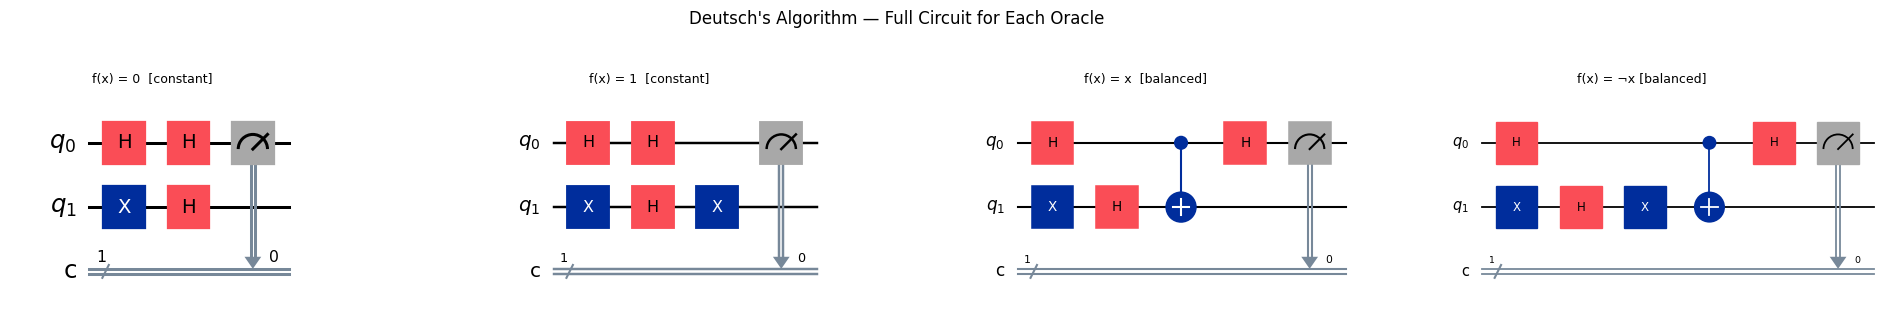

In [260]:
# visualise the full deutsch circuit for each oracle
fig, axes = plt.subplots(1, 4, figsize=(20, 3))

for ax, (name, oracle) in zip(axes, oracles.items()):
    qc = deutsch_circuit(oracle)
    qc.draw("mpl", ax=ax)
    ax.set_title(name, fontsize=9)

plt.suptitle("Deutsch's Algorithm — Full Circuit for Each Oracle", fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

### Determinism Check

Because the interference is total — the amplitude of the wrong answer is exactly zero — the result must be identical regardless of how many shots are used. A correct implementation never varies. This is not a probabilistic algorithm that gets the right answer most of the time.

In [261]:
# verify determinism — run each circuit multiple times with different shot counts
# a correct implementation should give the same answer regardless of how many shots we use
print("Determinism Check")
print("=" * 55)

for name, oracle in oracles.items():
    qc = deutsch_circuit(oracle)
    results = []

    for shots in [1, 10, 100, 1024]:
        counts = simulator.run(qc, shots=shots).result().get_counts()
        measured = "0" if "0" in counts else "1"
        results.append(measured)

    consistent = len(set(results)) == 1
    print(f"{name:<25} shots [1, 10, 100, 1024] -> {results}  {'CONSISTENT' if consistent else 'INCONSISTENT'}")

Determinism Check
f(x) = 0  [constant]      shots [1, 10, 100, 1024] -> ['0', '0', '0', '0']  CONSISTENT
f(x) = 1  [constant]      shots [1, 10, 100, 1024] -> ['0', '0', '0', '0']  CONSISTENT
f(x) = x  [balanced]      shots [1, 10, 100, 1024] -> ['1', '1', '1', '1']  CONSISTENT
f(x) = ¬x [balanced]      shots [1, 10, 100, 1024] -> ['1', '1', '1', '1']  CONSISTENT


### Results and Demonstration

All four oracles produced the correct classification across every shot count:

| Oracle | Measured | Classification |
|---|---|---|
| f(x) = 0 [constant] | 0 | Constant |
| f(x) = 1 [constant] | 0 | Constant |
| f(x) = x [balanced] | 1 | Balanced |
| f(x) = ¬x [balanced] | 1 | Balanced |

The determinism check confirmed the same result at 1, 10, 100, and 1024 shots for every oracle without exception. This is exactly what the interference mathematics from the lecture notes predicts — the amplitude of the wrong answer is exactly zero, so there is nothing to sample from. The result is not a probability, it is a certainty.

It is also worth noting that both constant oracles measure 0 and both balanced oracles measure 1, regardless of *which* constant or balanced function they implement. The algorithm cannot tell $f(x) = 0$ from $f(x) = 1$, or $f(x) = x$ from $f(x) = \neg x$ — it only classifies the type. That is all it is designed to do.

---

### Efficiency and Limitations

| Approach | Queries required |
|---|---|
| Classical (Problem 2) | 2 |
| Deutsch's algorithm | 1 |

The algorithm uses exactly one oracle call to produce a guaranteed correct answer. The classical approach from Problem 2 always needs two.

The main limitation is scope — this only works for single-input functions guaranteed to be constant or balanced. Feed it anything else and the result is meaningless. It also only tells you the *type*, not the specific function.

# Problem 5: Scaling to the Deutsch-Jozsa Algorithm

The Deutsch–Jozsa algorithm generalizes Deutsch's approach to functions with several input bits. Use Qiskit to create a quantum circuit that can handle the four-bit functions generated in Problem 1. Explain how the classical function is encoded as a quantum oracle, and demonstrate the use of your circuit on both of the constant functions and any two balanced functions of your choosing. Show that the circuit correctly identifies the type of each function.

In [262]:
def build_oracle(truth_table: list) -> QuantumCircuit:
    """
    Builds a 5-qubit oracle circuit from a 16-entry truth table.
    Qubits 0-3 are the inputs, qubit 4 is the ancilla.
    
    For each input where f(x) = 1, we flip the ancilla using an MCX gate.
    To make the MCX fire on 0-bits as well as 1-bits, we temporarily
    wrap those controls in X gates (the inverted-control trick).
    """
    if len(truth_table) != 16:
        raise ValueError(f"Expected 16 entries, got {len(truth_table)}")
    
    ones = sum(truth_table)
    
    if ones not in (0, 8, 16):
        raise ValueError(f"Function must be constant (0 or 16 ones) or balanced (8 ones), got {ones}")

    qc = QuantumCircuit(5, name="oracle")

    # constant 0: ancilla never flips — no gates needed
    if ones == 0:
        return qc

    # constant 1: ancilla always flips — one unconditional X is enough
    if ones == 16:
        qc.x(4)
        return qc

    # balanced: flip the ancilla for each input combination where f(x) = 1
    for index, value in enumerate(truth_table):
        if value == 1:
            # get the 4-bit pattern for this index, e.g. index 5 -> "0101"
            bits = format(index, '04b')

            # temporarily flip any qubit that should be 0
            # so the MCX fires on |0> at those positions
            for qubit, bit in enumerate(reversed(bits)):
                if bit == '0':
                    qc.x(qubit)

            # fire when all four controls match the target pattern
            qc.mcx([0, 1, 2, 3], 4)

            # restore the temporary flips for the next iteration
            for qubit, bit in enumerate(reversed(bits)):
                if bit == '0':
                    qc.x(qubit)

    return qc

In [263]:
def deutsch_jozsa(oracle: QuantumCircuit) -> QuantumCircuit:
    """
    Wraps an oracle in the full Deutsch-Jozsa circuit.
    
    Measuring 0000 means constant.
    Measuring anything else means balanced.
    """
    qc = QuantumCircuit(5, 4)

    # put the ancilla into |-> so phase kickback can work
    qc.x(4)
    qc.h(4)

    # put all four input qubits into equal superposition
    for i in range(4):
        qc.h(i)

    # query the oracle once — evaluates all 16 inputs simultaneously
    qc.compose(oracle, inplace=True)

    # interference step: constant -> 0000, balanced -> anything else
    for i in range(4):
        qc.h(i)

    # measure input register only, discard ancilla
    qc.measure(range(4), range(4))

    return qc

In [264]:
def classify(circuit: QuantumCircuit) -> str:
    """Runs the circuit and returns 'constant' or 'balanced'."""
    counts = simulator.run(circuit, shots=1024).result().get_counts()
    outcome = max(counts, key=counts.get)
    return "constant" if outcome == "0000" else "balanced"

In [265]:
# define test functions — both constants and three balanced cases.
# balanced C is drawn from random_constant_balanced (Problem 1)
# to show the full pipeline working end to end.

random.seed(42)
all_inputs = list(itertools.product([False, True], repeat=4))

# pull a balanced function from Problem 1
rng = random.Random(99)
while True:
    candidate = random_constant_balanced(rng)
    tt_candidate = [int(candidate(*inp)) for inp in all_inputs]
    if sum(tt_candidate) == 8:
        break

test_functions = {
    "Constant 0  (always returns 0)":    [0] * 16,
    "Constant 1  (always returns 1)":    [1] * 16,
    "Balanced A  (first 8 inputs = 1)":  [1]*8 + [0]*8,
    "Balanced B  (alternating 1, 0)":    [1 if i % 2 == 0 else 0 for i in range(16)],
    "Balanced C  (from Problem 1 RNG)":  tt_candidate,
}

In [266]:
# classification results
print(f"{'Function':<40} {'Outcome':<10} {'Classification'}")
print("-" * 65)

for name, tt in test_functions.items():
    circuit = deutsch_jozsa(build_oracle(tt))
    outcome = max(
        simulator.run(circuit, shots=1024).result().get_counts(),
        key=lambda k: simulator.run(circuit, shots=1024).result().get_counts()[k]
    )
    result = classify(circuit)
    print(f"{name:<40} {outcome:<10} {result}")

Function                                 Outcome    Classification
-----------------------------------------------------------------
Constant 0  (always returns 0)           0000       constant
Constant 1  (always returns 1)           0000       constant
Balanced A  (first 8 inputs = 1)         1000       balanced
Balanced B  (alternating 1, 0)           0001       balanced
Balanced C  (from Problem 1 RNG)         0101       balanced


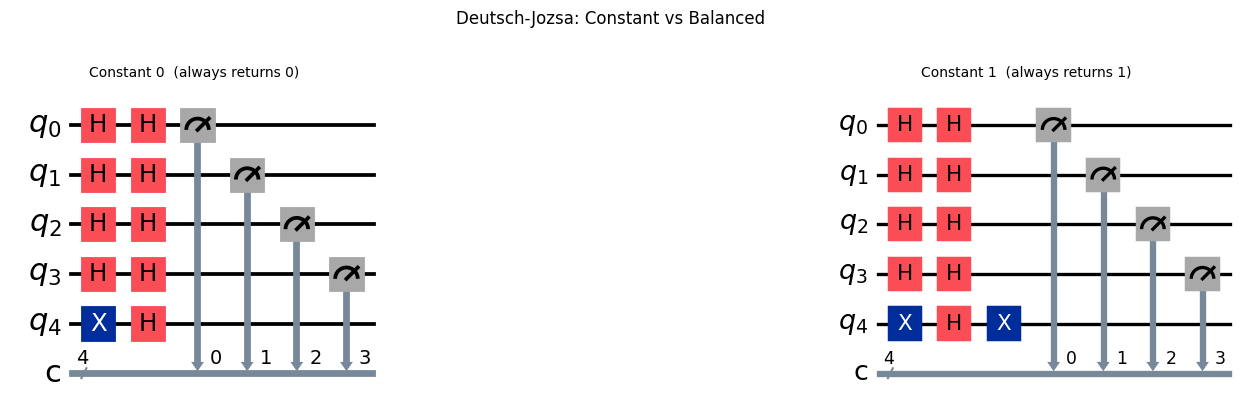

In [267]:
# circuit diagrams for a constant and a balanced example
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

for ax, (name, tt) in zip(axes, list(test_functions.items())[:2]):
    deutsch_jozsa(build_oracle(tt)).draw("mpl", ax=ax)
    ax.set_title(name, fontsize=10)

plt.suptitle("Deutsch-Jozsa: Constant vs Balanced", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [268]:
# gate cost: how many gates does each oracle add?
# on real hardware MCX gates decompose into many elementary CX gates
print(f"{'Function':<40} {'Oracle gates':<15} {'Transpiled CX':<15} {'Transpiled U'}")
print("-" * 80)

for name, tt in test_functions.items():
    oracle = build_oracle(tt)
    raw    = sum(oracle.count_ops().values())

    transpiled = transpile(deutsch_jozsa(oracle), simulator, basis_gates=['cx', 'u'])
    cx = transpiled.count_ops().get('cx', 0)
    u  = transpiled.count_ops().get('u', 0)

    print(f"{name:<40} {raw:<15} {cx:<15} {u}")

Function                                 Oracle gates    Transpiled CX   Transpiled U
--------------------------------------------------------------------------------
Constant 0  (always returns 0)           0               0               1
Constant 1  (always returns 1)           1               0               1


/home/codespace/.local/lib/python3.12/site-packages/qiskit/compiler/transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(
/home/codespace/.local/lib/python3.12/site-packages/qiskit/compiler/transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


Balanced A  (first 8 inputs = 1)         48              288             331
Balanced B  (alternating 1, 0)           48              288             330
Balanced C  (from Problem 1 RNG)         36              288             330


/home/codespace/.local/lib/python3.12/site-packages/qiskit/compiler/transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(
/home/codespace/.local/lib/python3.12/site-packages/qiskit/compiler/transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


In [269]:
# shot robustness: result must be identical at any shot count
# because interference is total — the wrong answer has zero amplitude
print(f"{'Function':<40} 1 shot     32 shots   1024 shots")
print("-" * 70)

for name, tt in test_functions.items():
    circuit = deutsch_jozsa(build_oracle(tt))
    results = [classify(circuit) for _ in [1, 32, 1024]]
    consistent = "OK" if len(set(results)) == 1 else "FAIL"
    print(f"{name:<40} {results[0]:<11}{results[1]:<11}{results[2]:<11}{consistent}")

Function                                 1 shot     32 shots   1024 shots
----------------------------------------------------------------------
Constant 0  (always returns 0)           constant   constant   constant   OK


Constant 1  (always returns 1)           constant   constant   constant   OK
Balanced A  (first 8 inputs = 1)         balanced   balanced   balanced   OK
Balanced B  (alternating 1, 0)           balanced   balanced   balanced   OK
Balanced C  (from Problem 1 RNG)         balanced   balanced   balanced   OK


In [270]:
# end-to-end: classical (Problem 2) vs Deutsch-Jozsa
# shows the query gap concretely across 10 random functions

random.seed(42)
functions = [random_constant_balanced() for _ in range(10)]

print(f"{'#':<4} {'Classical':<12} {'Queries':<10} {'Quantum':<12} {'Queries':<10} Match")
print("-" * 55)

for i, fn in enumerate(functions):
    classical_label, classical_queries = determine_constant_balanced_counted(fn)

    tt             = [int(fn(*inp)) for inp in all_inputs]
    quantum_label  = classify(deutsch_jozsa(build_oracle(tt)))
    match          = "YES" if classical_label == quantum_label else "NO"

    print(f"{i+1:<4} {classical_label:<12} {classical_queries:<10} {quantum_label:<12} {'1':<10} {match}")

#    Classical    Queries    Quantum      Queries    Match
-------------------------------------------------------
1    constant     9          constant     1          YES
2    balanced     2          balanced     1          YES
3    balanced     3          balanced     1          YES
4    constant     9          constant     1          YES
5    constant     9          constant     1          YES
6    balanced     2          balanced     1          YES
7    constant     9          constant     1          YES
8    balanced     2          balanced     1          YES
9    constant     9          constant     1          YES
10   constant     9          constant     1          YES
